<a href="https://colab.research.google.com/github/carraci/ai-Practical/blob/main/ai_practal_1_to_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
1 )Breadth First Search & Iterative Depth First Search

BFS Path : A -> B -> E -> G
DFS Path : A -> B -> E -> G


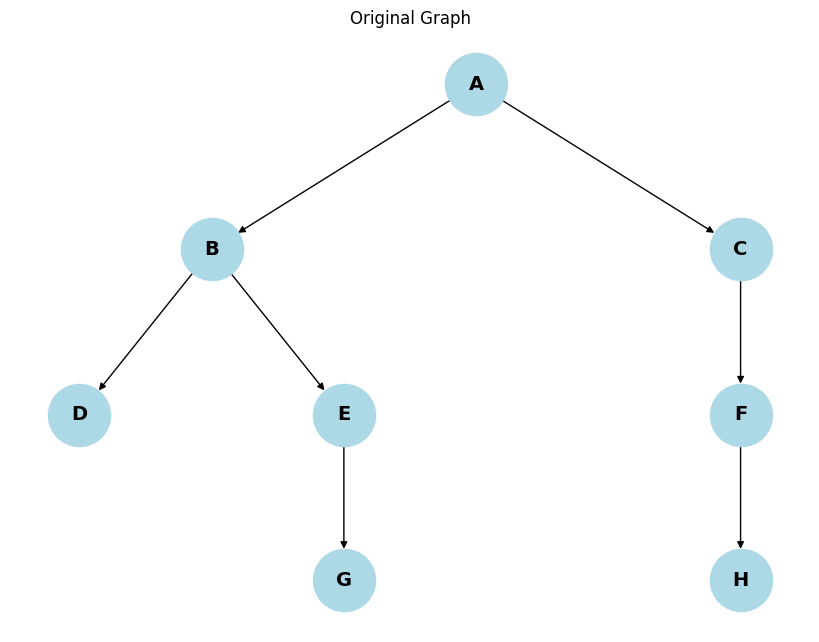

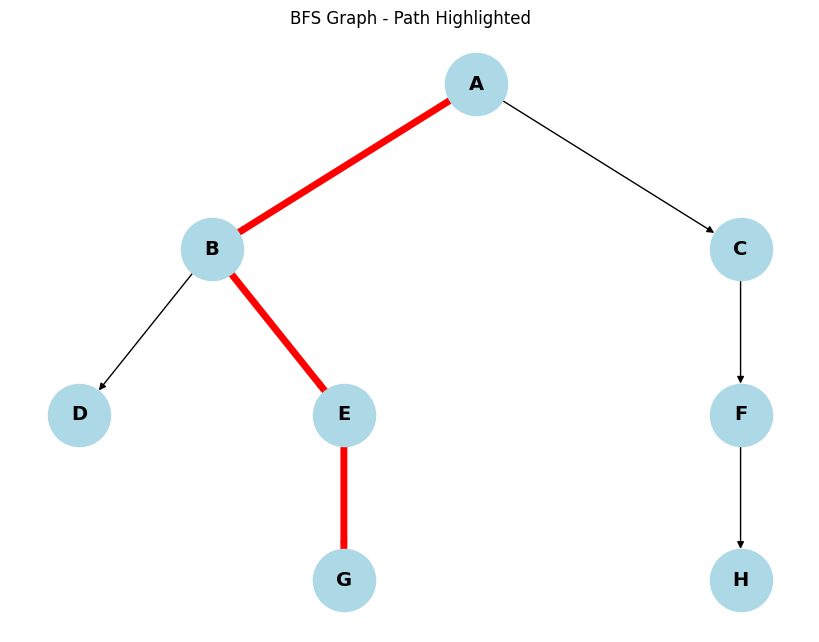

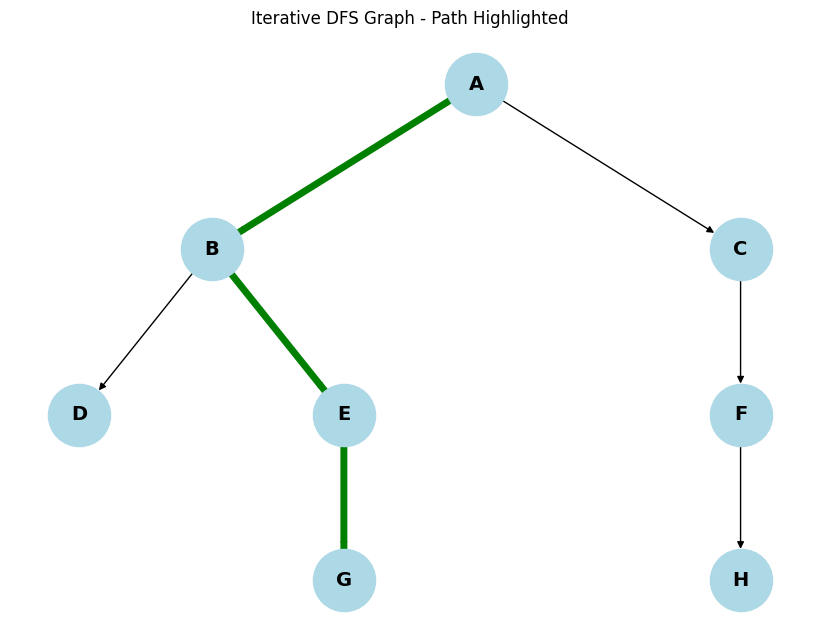

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque

graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': [],
    'E': ['G'],
    'F': ['H'],
    'G': [],
    'H': []
}

def bfs(start, goal):
    queue = deque([[start]])
    visited = set()

    while queue:
        path = queue.popleft()
        node = path[-1]

        if node in visited:
            continue

        visited.add(node)

        if node == goal:
            return path

        for neighbour in graph[node]:
            if neighbour not in visited:
                queue.append(path + [neighbour])

    return None

def iterative_dfs(start, goal):
    stack = [[start]]
    visited = set()

    while stack:
        path = stack.pop()
        node = path[-1]

        if node in visited:
            continue

        visited.add(node)

        if node == goal:
            return path

        for neighbour in reversed(graph[node]):
            if neighbour not in visited:
                stack.append(path + [neighbour])

    return None

start = 'A'
goal = 'G'

bfs_path = bfs(start, goal)
dfs_path = iterative_dfs(start, goal)

print("BFS Path :", " -> ".join(bfs_path))
print("DFS Path :", " -> ".join(dfs_path))

G = nx.DiGraph()

for node in graph:
    for neighbour in graph[node]:
        G.add_edge(node, neighbour)

pos = {
    'A': (0, 3),
    'B': (-2, 2),
    'C': (2, 2),
    'D': (-3, 1),
    'E': (-1, 1),
    'F': (2, 1),
    'G': (-1, 0),
    'H': (2, 0)
}

plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color='lightblue',
    font_size=14,
    font_weight='bold',
    arrows=True
)

plt.title("Original Graph")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color='lightblue',
    font_size=14,
    font_weight='bold',
    arrows=True
)

bfs_edges = list(zip(bfs_path, bfs_path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=bfs_edges,
    width=5,
    edge_color='red',
    arrows=True
)

plt.title("BFS Graph - Path Highlighted")
plt.axis('off')
plt.show()

plt.figure(figsize=(8, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    node_color='lightblue',
    font_size=14,
    font_weight='bold',
    arrows=True
)

dfs_edges = list(zip(dfs_path, dfs_path[1:]))

nx.draw_networkx_edges(
    G,
    pos,
    edgelist=dfs_edges,
    width=5,
    edge_color='green',
    arrows=True
)

plt.title("Iterative DFS Graph - Path Highlighted")
plt.axis('off')
plt.show()

2) A* Search and Recursive Best-First Search


Implement the A* Search algorithm for solving a pathfinding problem.




Visiting: MVLU College | g(n) = 0 | h(n) = 22 | f(n) = 22
Visiting: Bandra | g(n) = 12 | h(n) = 14 | f(n) = 26
Visiting: Sion | g(n) = 14 | h(n) = 13 | f(n) = 27
Visiting: Worli | g(n) = 18 | h(n) = 9 | f(n) = 27
Visiting: Byculla | g(n) = 22 | h(n) = 7 | f(n) = 29
Visiting: CSMT | g(n) = 27 | h(n) = 2 | f(n) = 29
Visiting: Gateway of India | g(n) = 30 | h(n) = 0 | f(n) = 30

A* SEARCH RESULT
Optimal Path: MVLU College -> Bandra -> Worli -> CSMT -> Gateway of India
Total Road Distance: 30 km


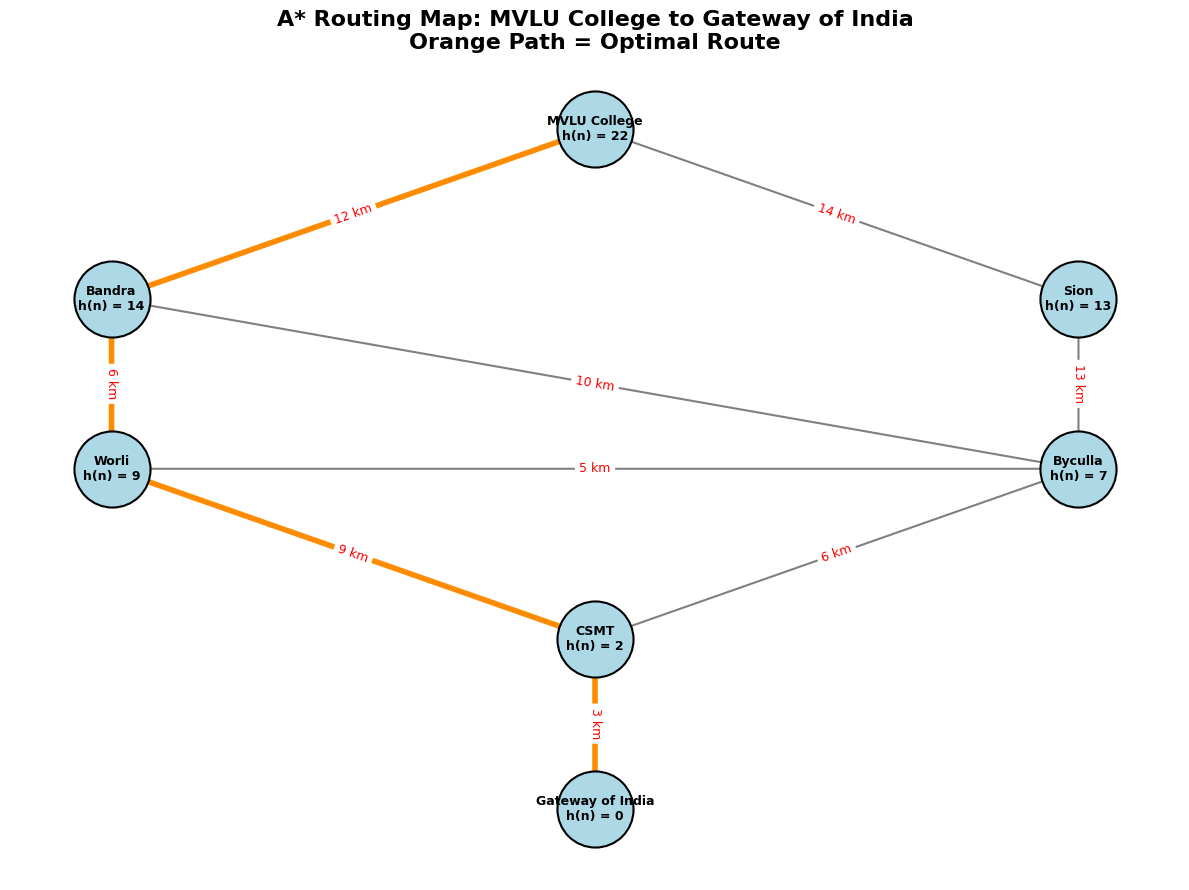

In [3]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

graph = {
    'MVLU College': {'Bandra': 12, 'Sion': 14},
    'Bandra': {'Worli': 6, 'Byculla': 10},
    'Sion': {'Byculla': 13},
    'Worli': {'Byculla': 5, 'CSMT': 9},
    'Byculla': {'CSMT': 6},
    'CSMT': {'Gateway of India': 3},
    'Gateway of India': {}
}

heuristics = {
    'MVLU College': 22,
    'Bandra': 14,
    'Sion': 13,
    'Worli': 9,
    'Byculla': 7,
    'CSMT': 2,
    'Gateway of India': 0
}

node_positions = {
    'MVLU College': (2, 8),
    'Bandra': (1, 6),
    'Sion': (3, 6),
    'Worli': (1, 4),
    'Byculla': (3, 4),
    'CSMT': (2, 2),
    'Gateway of India': (2, 0)
}

def a_star_search(graph, heuristics, start, goal):
    priority_queue = [
        (heuristics[start], start, [start], 0)
    ]

    visited = set()

    while priority_queue:
        f_score, current, path, g_score = heapq.heappop(
            priority_queue
        )

        if current in visited:
            continue

        visited.add(current)

        print(
            f"Visiting: {current} | "
            f"g(n) = {g_score} | "
            f"h(n) = {heuristics[current]} | "
            f"f(n) = {f_score}"
        )

        if current == goal:
            return path, g_score

        for neighbor, edge_weight in graph[current].items():
            if neighbor not in visited:
                next_g = g_score + edge_weight
                next_f = next_g + heuristics[neighbor]

                heapq.heappush(
                    priority_queue,
                    (
                        next_f,
                        neighbor,
                        path + [neighbor],
                        next_g
                    )
                )

    return None, float('inf')

start = 'MVLU College'
goal = 'Gateway of India'

optimal_path, total_distance = a_star_search(
    graph,
    heuristics,
    start,
    goal
)

print("\n" + "=" * 60)
print("A* SEARCH RESULT")
print("=" * 60)

print(
    "Optimal Path:",
    " -> ".join(optimal_path)
)

print(
    "Total Road Distance:",
    total_distance,
    "km"
)

G = nx.DiGraph()

for node, neighbors in graph.items():
    for neighbor, weight in neighbors.items():
        G.add_edge(
            node,
            neighbor,
            weight=weight
        )

plt.figure(figsize=(12, 9))

path_edges = list(
    zip(
        optimal_path,
        optimal_path[1:]
    )
)

normal_edges = [
    edge
    for edge in G.edges()
    if edge not in path_edges
]

nx.draw_networkx_nodes(
    G,
    node_positions,
    node_size=3000,
    node_color='lightblue',
    edgecolors='black',
    linewidths=1.5
)

nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=normal_edges,
    width=1.5,
    edge_color='gray',
    arrows=True,
    arrowsize=20
)

nx.draw_networkx_edges(
    G,
    node_positions,
    edgelist=path_edges,
    width=4,
    edge_color='darkorange',
    arrows=True,
    arrowsize=25
)

node_labels = {
    node: f"{node}\nh(n) = {heuristics[node]}"
    for node in G.nodes()
}

nx.draw_networkx_labels(
    G,
    node_positions,
    labels=node_labels,
    font_size=9,
    font_weight='bold'
)

edge_labels = nx.get_edge_attributes(
    G,
    'weight'
)

formatted_edge_labels = {
    edge: f"{weight} km"
    for edge, weight in edge_labels.items()
}

nx.draw_networkx_edge_labels(
    G,
    node_positions,
    edge_labels=formatted_edge_labels,
    font_size=9,
    font_color='red'
)

plt.title(
    "A* Routing Map: MVLU College to Gateway of India\n"
    "Orange Path = Optimal Route",
    fontsize=16,
    fontweight='bold'
)

plt.axis('off')
plt.tight_layout()
plt.show()

Implement the Recursive Best-First Search algorithm for the same problem.

RECURSIVE BEST-FIRST SEARCH (RBFS)
Optimal RBFS Path:
MVLU -> Bandra -> Worli -> CSMT -> Gateway
Total Distance: 30 km


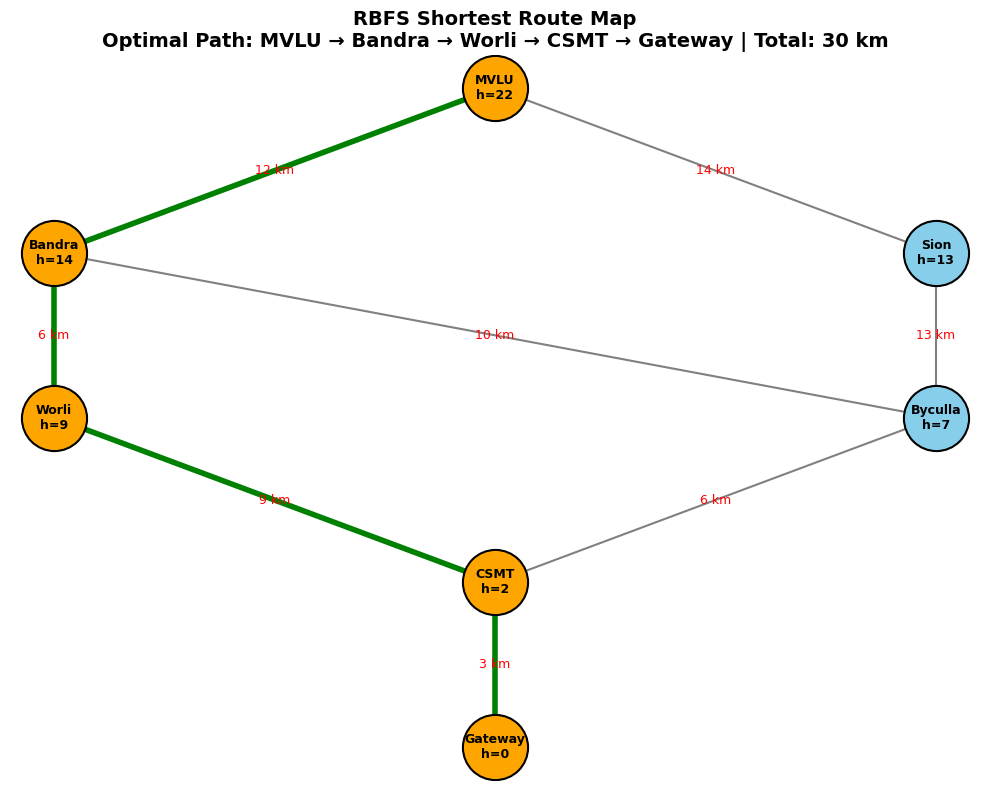

In [4]:
import matplotlib.pyplot as plt

graph = {
    'MVLU': {'Bandra': 12, 'Sion': 14},
    'Bandra': {'Worli': 6, 'Byculla': 10},
    'Sion': {'Byculla': 13},
    'Worli': {'CSMT': 9},
    'Byculla': {'CSMT': 6},
    'CSMT': {'Gateway': 3},
    'Gateway': {}
}

heuristics = {
    'MVLU': 22,
    'Bandra': 14,
    'Sion': 13,
    'Worli': 9,
    'Byculla': 7,
    'CSMT': 2,
    'Gateway': 0
}

coords = {
    'MVLU': (2, 6),
    'Bandra': (1, 4.5),
    'Sion': (3, 4.5),
    'Worli': (1, 3),
    'Byculla': (3, 3),
    'CSMT': (2, 1.5),
    'Gateway': (2, 0)
}

def rbfs_search(start, goal):
    success, path, cost, _ = rbfs(
        start,
        goal,
        g=0,
        f_limit=float('inf'),
        path=[start]
    )

    if success:
        return path, cost

    return [], float('inf')


def rbfs(node, goal, g, f_limit, path):

    if node == goal:
        return True, path, g, g

    neighbors = graph[node]

    if not neighbors:
        return False, [], 0, float('inf')

    successors = []

    for neighbor, distance in neighbors.items():

        if neighbor not in path:

            next_g = g + distance

            next_f = max(
                next_g + heuristics[neighbor],
                g + heuristics[node]
            )

            successors.append(
                [next_f, neighbor, next_g]
            )

    if not successors:
        return False, [], 0, float('inf')

    while True:

        successors.sort(key=lambda x: x[0])

        best = successors[0]

        if best[0] > f_limit:
            return False, [], 0, best[0]

        if len(successors) > 1:
            alternative_f = successors[1][0]
        else:
            alternative_f = float('inf')

        success, result_path, total_g, returned_f = rbfs(
            best[1],
            goal,
            best[2],
            min(f_limit, alternative_f),
            path + [best[1]]
        )

        best[0] = returned_f

        if success:
            return True, result_path, total_g, returned_f


path, total_dist = rbfs_search('MVLU', 'Gateway')

print("=" * 55)
print("RECURSIVE BEST-FIRST SEARCH (RBFS)")
print("=" * 55)

print("Optimal RBFS Path:")
print(" -> ".join(path))

print("Total Distance:", total_dist, "km")

plt.figure(figsize=(10, 8))

for node, neighbors in graph.items():

    x1, y1 = coords[node]

    for neighbor, dist in neighbors.items():

        x2, y2 = coords[neighbor]

        is_path = (
            node in path
            and neighbor in path
            and path.index(neighbor) == path.index(node) + 1
        )

        if is_path:
            line_color = 'green'
            line_width = 4
        else:
            line_color = 'gray'
            line_width = 1.5

        plt.plot(
            [x1, x2],
            [y1, y2],
            color=line_color,
            linewidth=line_width,
            zorder=1
        )

        plt.text(
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            f"{dist} km",
            color='red',
            fontsize=9,
            ha='center',
            va='center'
        )

for node, (x, y) in coords.items():

    if node in path:
        node_color = 'orange'
    else:
        node_color = 'skyblue'

    plt.scatter(
        x,
        y,
        color=node_color,
        s=2200,
        edgecolors='black',
        linewidths=1.5,
        zorder=2
    )

    plt.text(
        x,
        y,
        f"{node}\nh={heuristics[node]}",
        ha='center',
        va='center',
        color='black',
        fontsize=9,
        fontweight='bold',
        zorder=3
    )

plt.title(
    f"RBFS Shortest Route Map\n"
    f"Optimal Path: {' → '.join(path)} | Total: {total_dist} km",
    fontsize=14,
    fontweight='bold'
)

plt.axis('off')
plt.tight_layout()
plt.show()

Decision Tree Learning

 Implement the Decision Tree Learning algorithm to build a decision tree for
a given dataset.

Decision Tree Learning
Dataset Size: (150, 5)
Training Samples: 120
Testing Samples: 30
Accuracy: 96.67 %

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



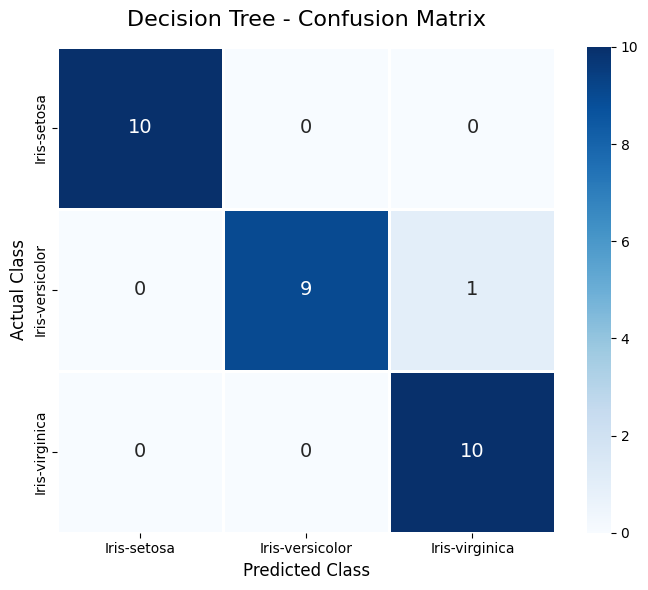

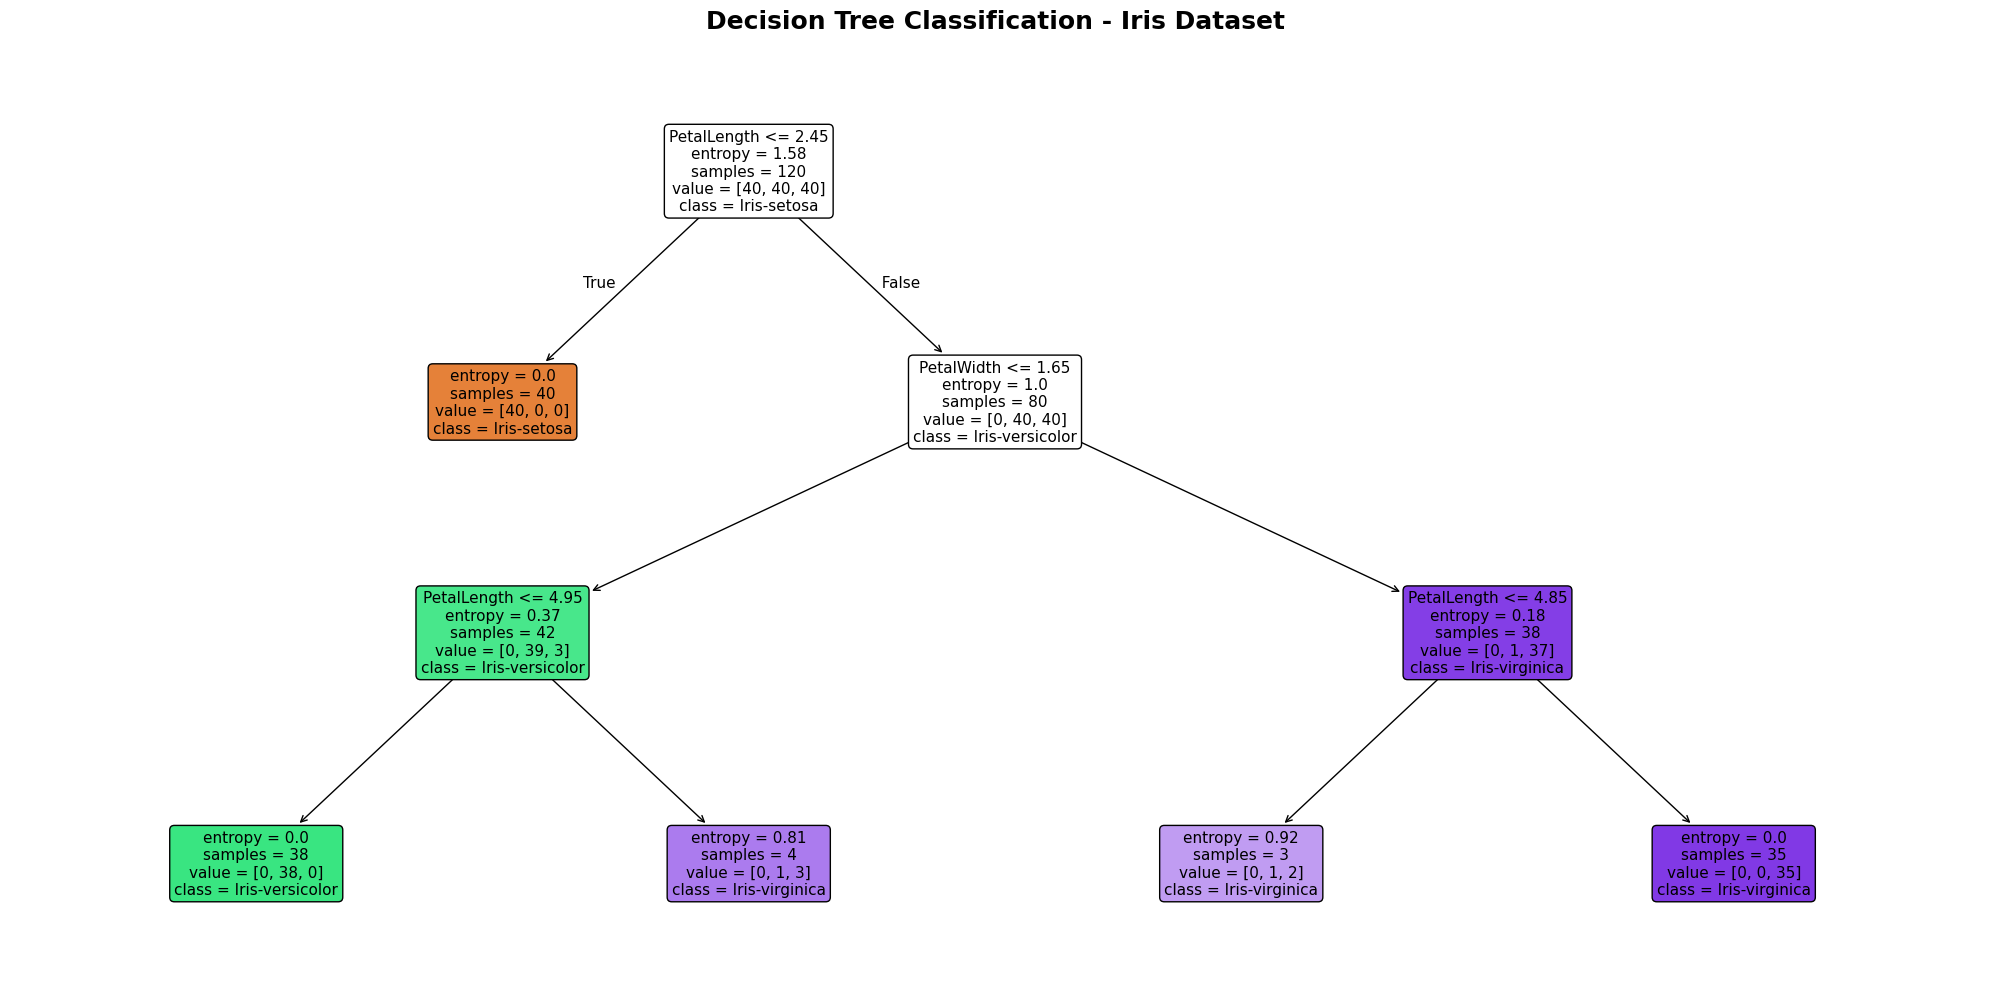

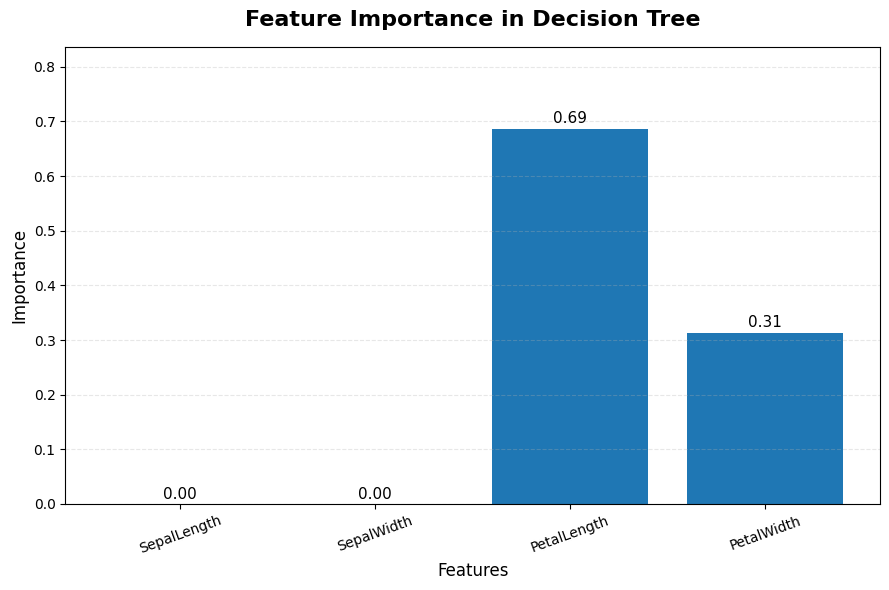


New Sample Prediction
Input: [[5.1, 3.5, 1.4, 0.2]]
Predicted Species: Iris-setosa


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth",
    "Species"
]

df = pd.read_csv(url, names=columns)
df.dropna(inplace=True)

X = df[["SepalLength", "SepalWidth", "PetalLength", "PetalWidth"]]
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Learning")
print("======================")
print("Dataset Size:", df.shape)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="white",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    annot_kws={"size": 14}
)

plt.title("Decision Tree - Confusion Matrix", fontsize=16, pad=15)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)
plt.tight_layout()
plt.show()


plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    precision=2,
    fontsize=11
)

plt.title(
    "Decision Tree Classification - Iris Dataset",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()


importance = model.feature_importances_

plt.figure(figsize=(9, 6))

bars = plt.bar(
    X.columns,
    importance
)

plt.title(
    "Feature Importance in Decision Tree",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Features", fontsize=12)
plt.ylabel("Importance", fontsize=12)

plt.xticks(rotation=20)

for bar, value in zip(bars, importance):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.2f}",
        ha="center",
        fontsize=11
    )

plt.ylim(0, max(importance) + 0.15)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


new_sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(new_sample)

print("\nNew Sample Prediction")
print("=====================")
print("Input:", new_sample)
print("Predicted Species:", prediction[0])

Evaluate the accuracy and effectiveness of the decision tree on test data.

Decision Tree Evaluation
Training Samples: 120
Testing Samples: 30
Correct Predictions: 29
Incorrect Predictions: 1
Accuracy: 96.67 %

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


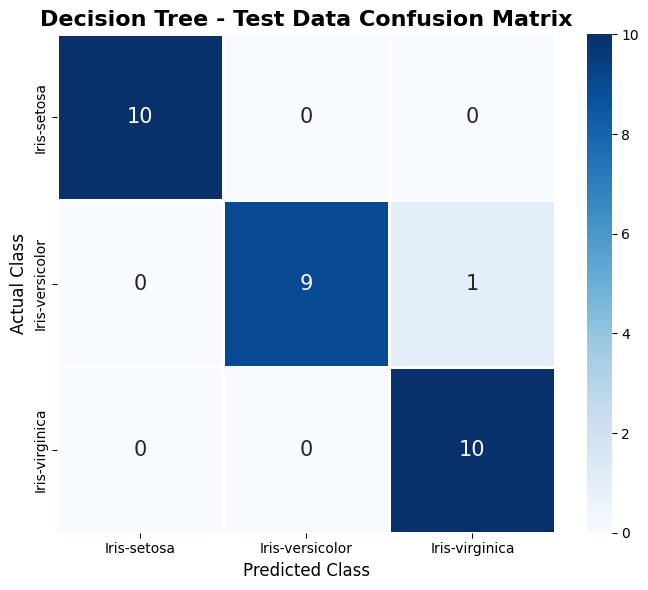

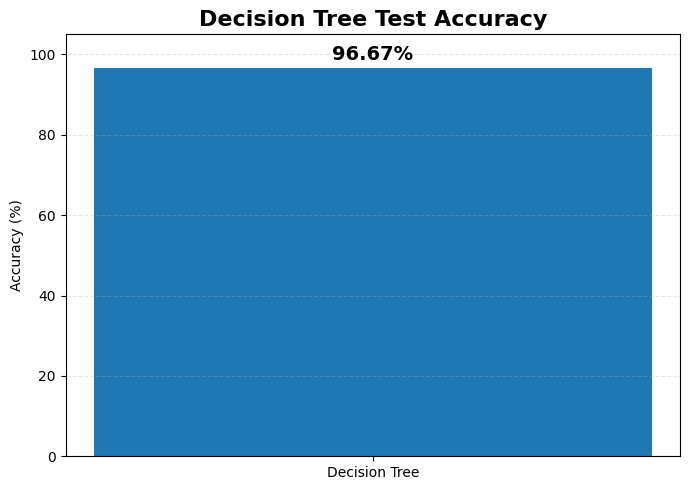

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

columns = [
    "SepalLength",
    "SepalWidth",
    "PetalLength",
    "PetalWidth",
    "Species"
]

df = pd.read_csv(url, names=columns)
df.dropna(inplace=True)

X = df[["SepalLength", "SepalWidth", "PetalLength", "PetalWidth"]]
y = df["Species"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Evaluation")
print("========================")
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Correct Predictions:", sum(y_test == y_pred))
print("Incorrect Predictions:", sum(y_test != y_pred))
print("Accuracy:", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=1,
    linecolor="white",
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    annot_kws={"size": 15}
)

plt.title("Decision Tree - Test Data Confusion Matrix",
          fontsize=16, fontweight="bold")

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Decision Tree"],
    [accuracy * 100],
    width=0.5
)

plt.ylabel("Accuracy (%)")
plt.title("Decision Tree Test Accuracy",
          fontsize=16, fontweight="bold")

plt.ylim(0, 105)

plt.text(
    0,
    accuracy * 100 + 2,
    f"{accuracy * 100:.2f}%",
    ha="center",
    fontsize=14,
    fontweight="bold"
)

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

Visualize and interpret the generated decision tree.

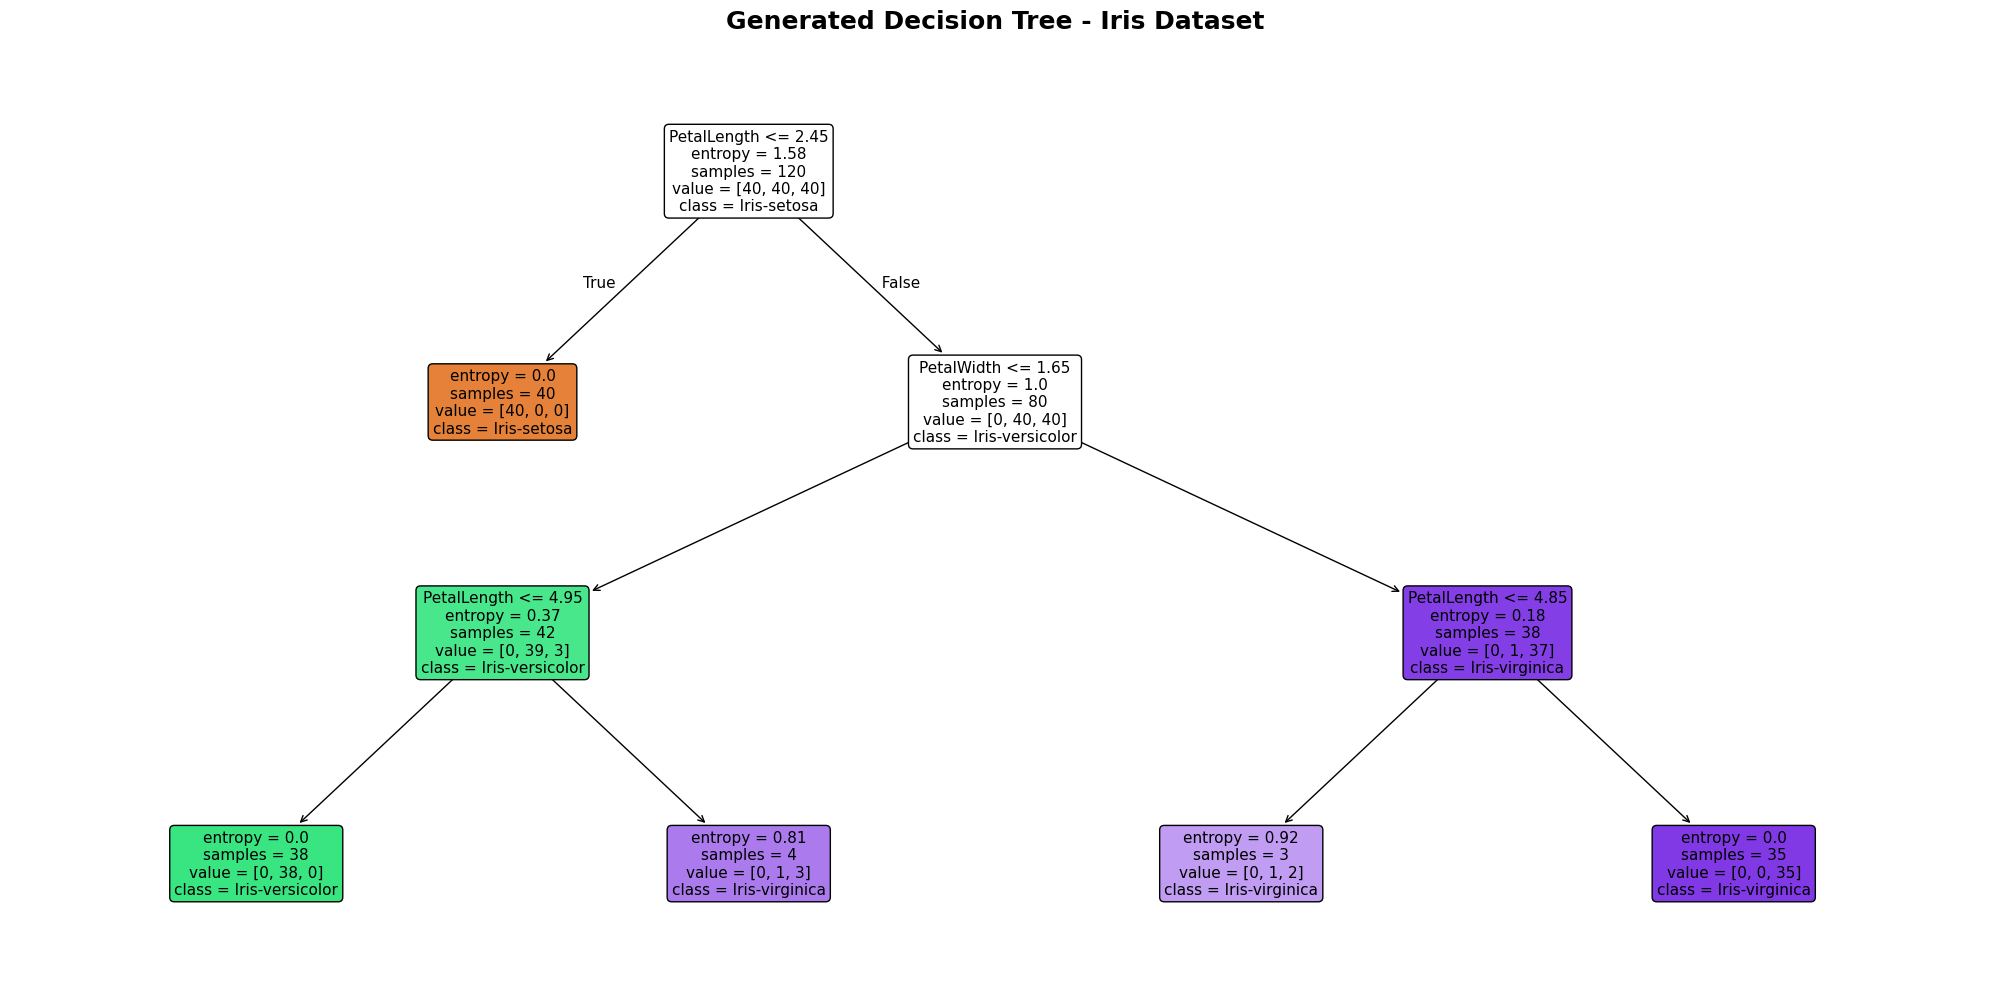


Decision Tree Interpretation
Root feature: PetalLength

The decision tree classifies Iris flowers using:
1. Sepal Length
2. Sepal Width
3. Petal Length
4. Petal Width

Interpretation:
The tree starts from the root node and checks the most important feature.
Each internal node represents a decision condition.
The branches represent the outcome of the condition.
The leaf nodes represent the final predicted species.
The tree can classify flowers as Iris-setosa, Iris-versicolor, or Iris-virginica.


In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=model.classes_,
    filled=True,
    rounded=True,
    fontsize=11,
    precision=2
)

plt.title(
    "Generated Decision Tree - Iris Dataset",
    fontsize=18,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

print("\nDecision Tree Interpretation")
print("============================")

print("Root feature:", X.columns[model.tree_.feature[0]])

print("\nThe decision tree classifies Iris flowers using:")
print("1. Sepal Length")
print("2. Sepal Width")
print("3. Petal Length")
print("4. Petal Width")

print("\nInterpretation:")
print("The tree starts from the root node and checks the most important feature.")
print("Each internal node represents a decision condition.")
print("The branches represent the outcome of the condition.")
print("The leaf nodes represent the final predicted species.")
print("The tree can classify flowers as Iris-setosa, Iris-versicolor, or Iris-virginica.")

In [ ]:
4 )Feed Forward Backpropagation Neural Network

DATASET
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768

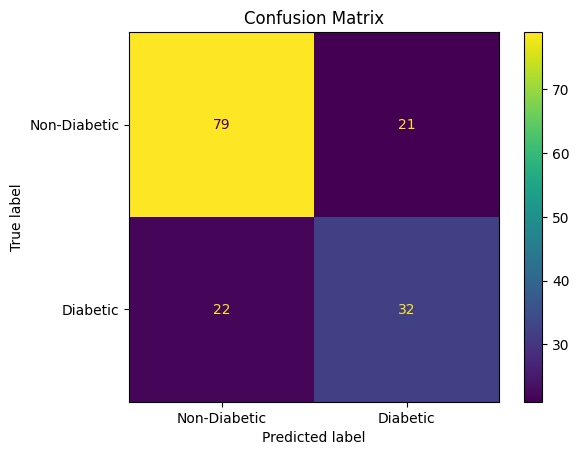

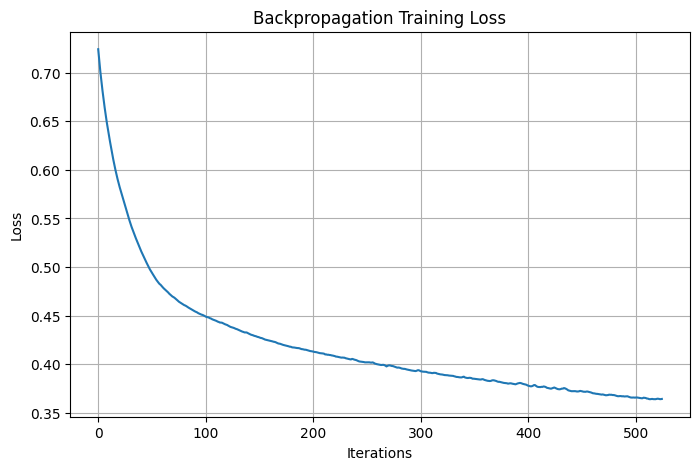

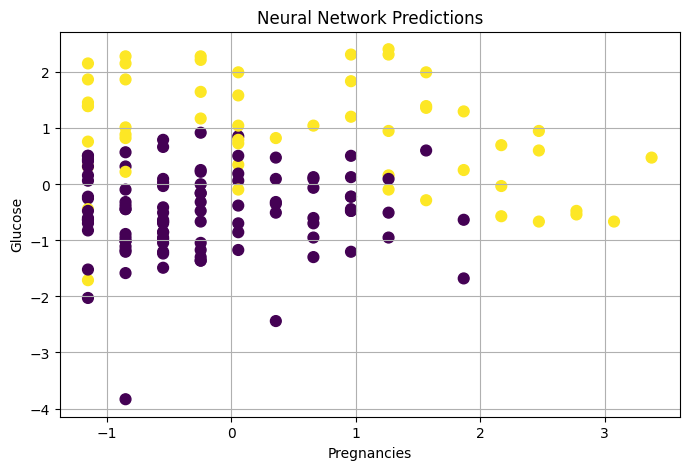


Actual vs Predicted:
    Actual  Predicted
0        0          1
1        0          0
2        0          0
3        1          0
4        0          0
5        0          0
6        1          0
7        1          1
8        0          0
9        0          1
10       0          0
11       1          1
12       0          0
13       0          0
14       1          0
15       1          0
16       0          1
17       0          0
18       0          1
19       0          0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("DATASET")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    learning_rate_init=0.001,
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nFeed Forward Backpropagation Neural Network")
print("--------------------------------------------")
print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))
print("Accuracy        :", round(accuracy * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Diabetic", "Diabetic"]
    )
)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_)
plt.title("Backpropagation Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    s=60
)
plt.title("Neural Network Predictions")
plt.xlabel("Pregnancies")
plt.ylabel("Glucose")
plt.grid(True)
plt.show()

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(result.head(20))

Use a given dataset to train the neural network for a specific task.

Dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape: (768, 9)

Feed Forward Backpropagation Neural Network
--------------------------------------------
Training Samples: 614
Testing Samples : 154
Accuracy        : 72.08 %


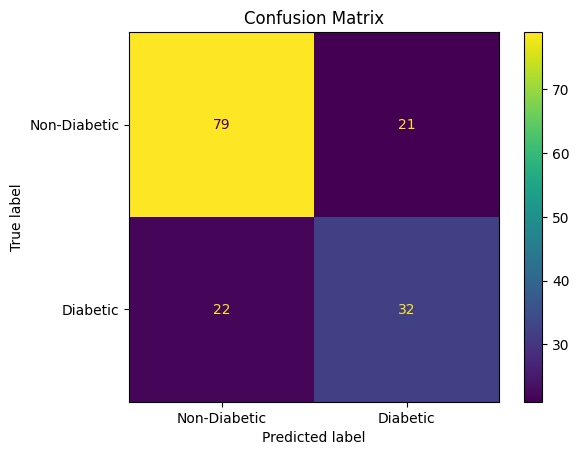

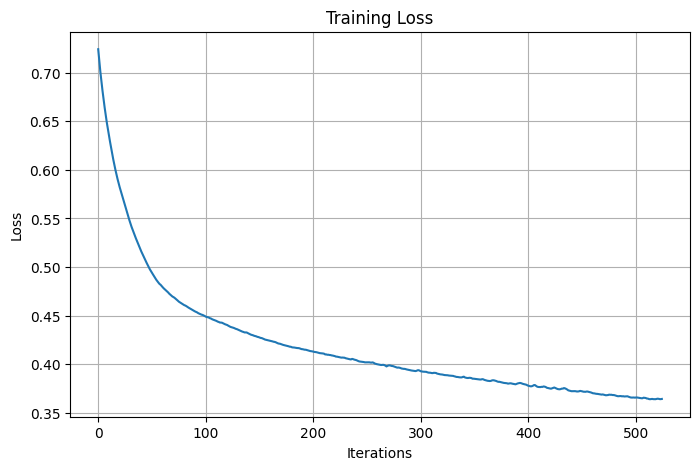

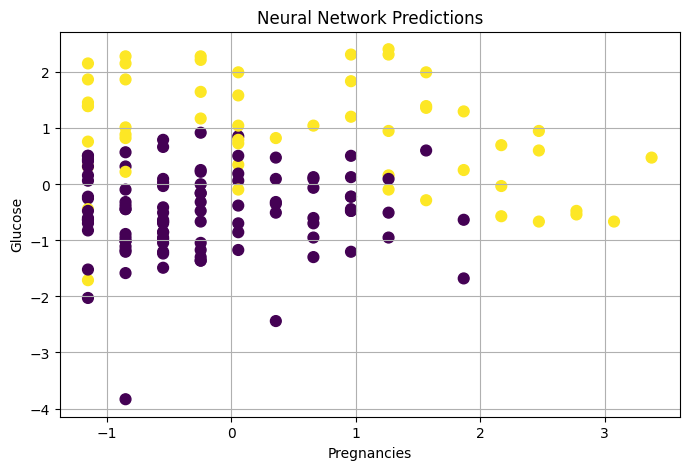

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(url, names=columns)

print("Dataset:")
print(df.head())

print("\nDataset Shape:", df.shape)

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = MLPClassifier(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("\nFeed Forward Backpropagation Neural Network")
print("--------------------------------------------")
print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))
print("Accuracy        :", round(accuracy * 100, 2), "%")

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(model.loss_curve_)
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_pred,
    s=60
)

plt.title("Neural Network Predictions")
plt.xlabel("Pregnancies")
plt.ylabel("Glucose")
plt.grid(True)
plt.show()

Evaluate the performance of the trained network on test data.

Neural Network Performance on Test Data
----------------------------------------
Accuracy  : 72.08 %
Precision : 60.38 %
Recall    : 59.26 %
F1-Score  : 59.81 %

Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.78      0.79      0.79       100
    Diabetic       0.60      0.59      0.60        54

    accuracy                           0.72       154
   macro avg       0.69      0.69      0.69       154
weighted avg       0.72      0.72      0.72       154


Confusion Matrix:
[[79 21]
 [22 32]]


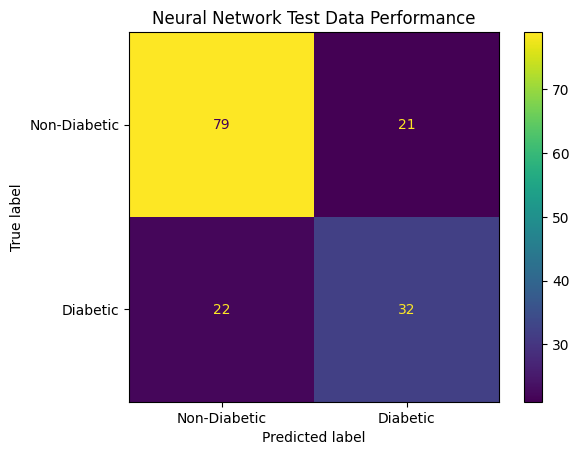

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Neural Network Performance on Test Data")
print("----------------------------------------")
print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1-Score  :", round(f1 * 100, 2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Non-Diabetic", "Diabetic"]
    )
)

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Diabetic", "Diabetic"]
)

disp.plot()
plt.title("Neural Network Test Data Performance")
plt.show()

5 )Support Vector Machines (SVM)


 Implement the SVM algorithm for binary classification.

Dataset Shape: (569, 32)

First 5 Rows:
         ID  Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302          1        17.99         10.38          122.80     1001.0   
1    842517          1        20.57         17.77          132.90     1326.0   
2  84300903          1        19.69         21.25          130.00     1203.0   
3  84348301          1        11.42         20.38           77.58      386.1   
4  84358402          1        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_w

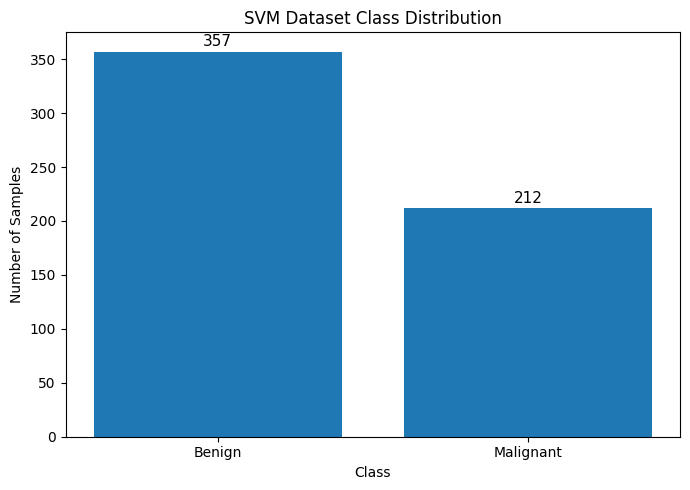

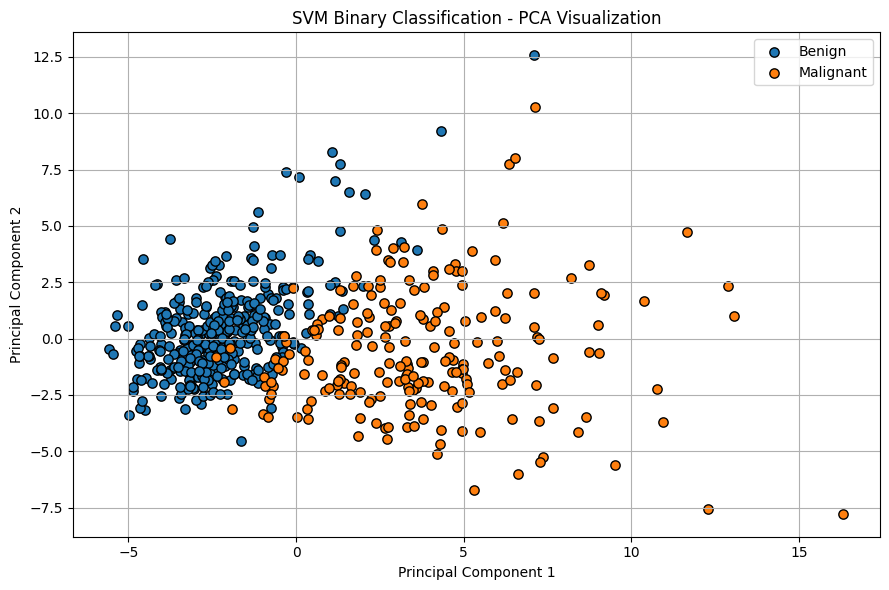

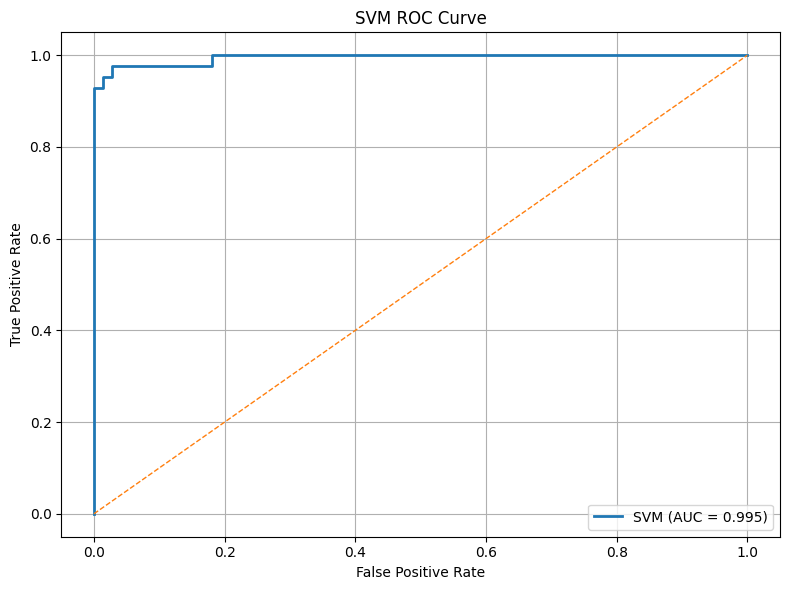

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(url, header=None, names=columns)

df["Diagnosis"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"]

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    probability=True,
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nSVM PERFORMANCE")
print("-----------------------------")
print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1 Score  :", round(f1 * 100, 2), "%")

print("\nClass Distribution")
print(df["Diagnosis"].value_counts())

plt.figure(figsize=(7, 5))

counts = df["Diagnosis"].value_counts().sort_index()

bars = plt.bar(
    ["Benign", "Malignant"],
    counts.values
)

plt.title("SVM Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")

for bar, value in zip(bars, counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 5,
        str(value),
        ha="center",
        fontsize=11
    )

plt.tight_layout()
plt.show()

pca = PCA(n_components=2)

X_pca = pca.fit_transform(
    StandardScaler().fit_transform(X)
)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[y == 0, 0],
    X_pca[y == 0, 1],
    label="Benign",
    s=45,
    edgecolors="black"
)

plt.scatter(
    X_pca[y == 1, 0],
    X_pca[y == 1, 1],
    label="Malignant",
    s=45,
    edgecolors="black"
)

plt.title("SVM Binary Classification - PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label="SVM (AUC = {:.3f})".format(roc_auc)
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.title("SVM ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Train an SVM model using a given dataset and optimize its parameters.

SVM PARAMETER OPTIMIZATION
Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross-Validation Accuracy: 97.58 %

TEST DATA PERFORMANCE
Accuracy  : 97.37 %
Precision : 100.0 %
Recall    : 92.86 %
F1 Score  : 96.3 %


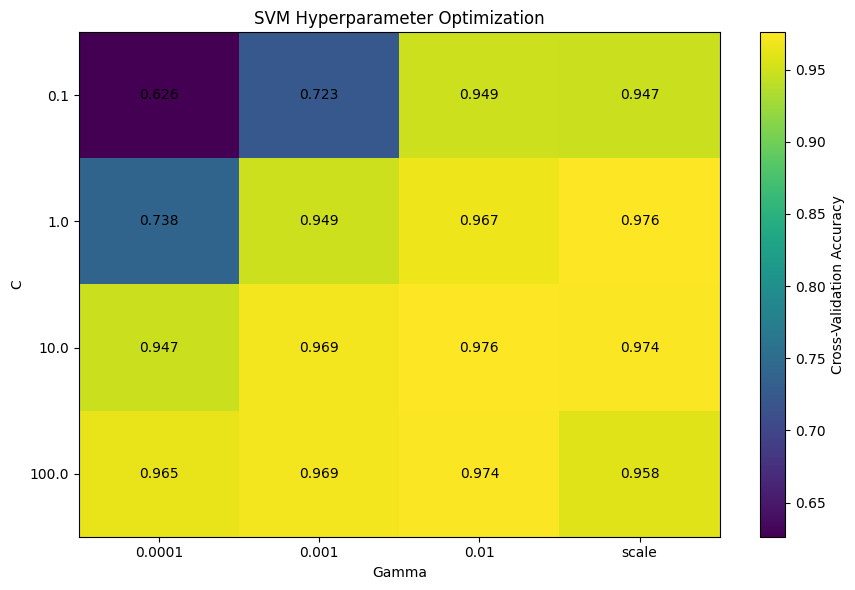

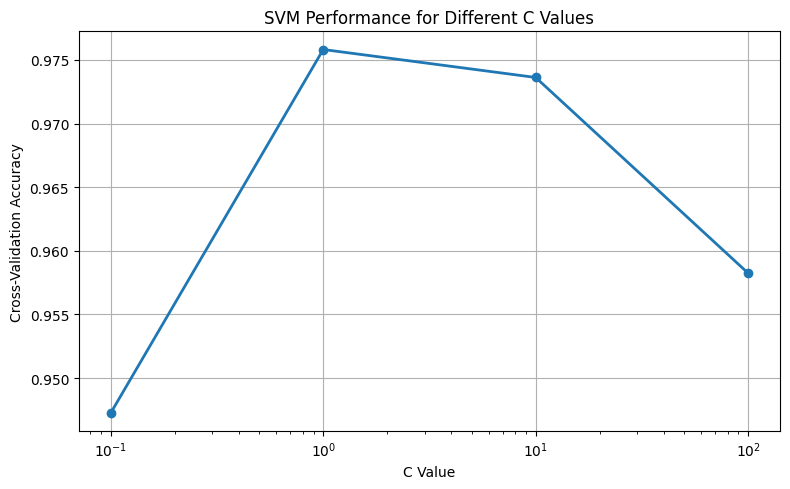

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(url, header=None, names=columns)

df["Diagnosis"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC()

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001, 0.0001],
    "kernel": ["rbf", "linear"]
}

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("SVM PARAMETER OPTIMIZATION")
print("==============================")

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation Accuracy:",
      round(grid_search.best_score_ * 100, 2), "%")

print("\nTEST DATA PERFORMANCE")
print("==============================")
print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1 Score  :", round(f1 * 100, 2), "%")

results = pd.DataFrame(grid_search.cv_results_)

rbf_results = results[
    results["param_kernel"] == "rbf"
].copy()

rbf_results["C"] = rbf_results["param_C"].astype(float)

rbf_results["gamma_value"] = rbf_results["param_gamma"].astype(str)

pivot_table = rbf_results.pivot_table(
    index="C",
    columns="gamma_value",
    values="mean_test_score"
)

plt.figure(figsize=(9, 6))

plt.imshow(
    pivot_table,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Cross-Validation Accuracy")

plt.xticks(
    range(len(pivot_table.columns)),
    pivot_table.columns
)

plt.yticks(
    range(len(pivot_table.index)),
    pivot_table.index
)

plt.xlabel("Gamma")
plt.ylabel("C")
plt.title("SVM Hyperparameter Optimization")

for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        value = pivot_table.iloc[i, j]
        plt.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

C_values = [0.1, 1, 10, 100]

best_scores = []

for c in C_values:
    mask = (
        (results["param_kernel"] == "rbf") &
        (results["param_C"].astype(float) == c) &
        (results["param_gamma"].astype(str) == "scale")
    )

    if mask.any():
        best_scores.append(
            results.loc[mask, "mean_test_score"].iloc[0]
        )

plt.figure(figsize=(8, 5))

plt.plot(
    C_values,
    best_scores,
    marker="o",
    linewidth=2
)

plt.xscale("log")

plt.xlabel("C Value")
plt.ylabel("Cross-Validation Accuracy")
plt.title("SVM Performance for Different C Values")
plt.grid(True)
plt.tight_layout()
plt.show()

Evaluate the performance of the SVM model on test data and analyze the
results.

SVM TEST DATA EVALUATION

Best Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}

Test Data Results:
----------------------------------------
Accuracy  : 97.37 %
Precision : 100.0 %
Recall    : 92.86 %
F1 Score  : 96.3 %

Classification Report:
----------------------------------------
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



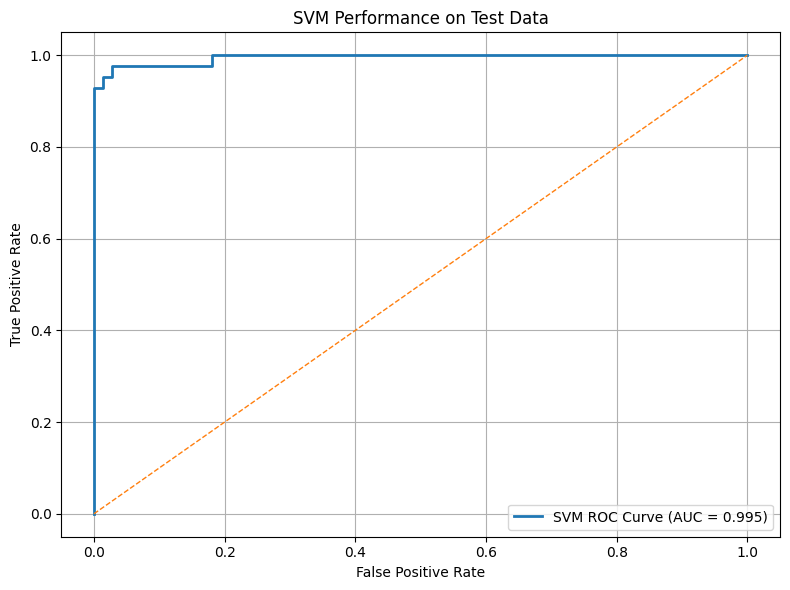

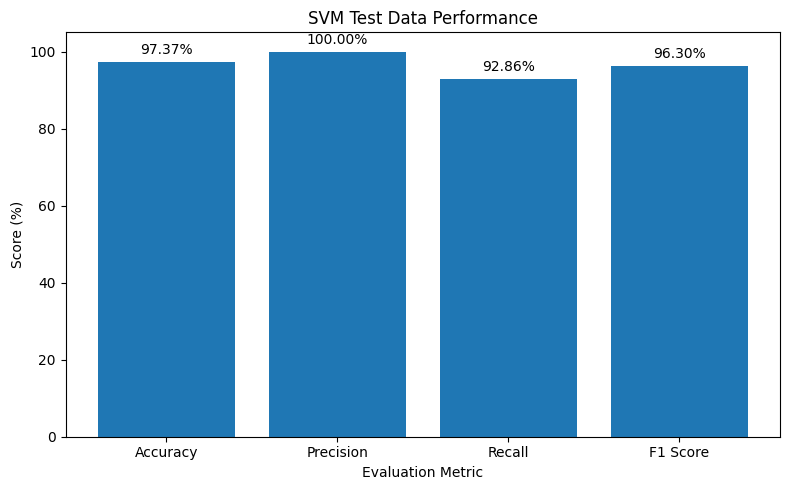

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    classification_report
)

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(url, header=None, names=columns)

df["Diagnosis"] = df["Diagnosis"].map({
    "B": 0,
    "M": 1
})

X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm = SVC()

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.01, 0.001, 0.0001],
    "kernel": ["rbf", "linear"]
}

grid_search = GridSearchCV(
    svm,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.decision_function(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("SVM TEST DATA EVALUATION")
print("=" * 40)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nTest Data Results:")
print("-" * 40)
print("Accuracy  :", round(accuracy * 100, 2), "%")
print("Precision :", round(precision * 100, 2), "%")
print("Recall    :", round(recall * 100, 2), "%")
print("F1 Score  :", round(f1 * 100, 2), "%")

print("\nClassification Report:")
print("-" * 40)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Benign", "Malignant"]
    )
)

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"SVM ROC Curve (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM Performance on Test Data")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

metrics = {
    "Accuracy": accuracy * 100,
    "Precision": precision * 100,
    "Recall": recall * 100,
    "F1 Score": f1 * 100
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0, 105)
plt.xlabel("Evaluation Metric")
plt.ylabel("Score (%)")
plt.title("SVM Test Data Performance")

for bar, value in zip(bars, metrics.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 2,
        f"{value:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()